In [140]:
import pandas as pd
import numpy as np
from pathlib import Path
import os
import sys
from glob import glob
import pypower
from pypower import idx_bus
from pypower import idx_gen
from pypower import idx_brch
from pypower import idx_cost
import pypsa
import geopandas as gpd
import us
import matplotlib.pyplot as plt

In [77]:
gen_idxs = [atr for atr in dir(idx_gen) if '__' not in atr]
gen_header_map = {getattr(idx_gen, atr):atr for atr in gen_idxs}

In [78]:
bus_idxs = [atr for atr in dir(idx_bus) if '__' not in atr]
bus_col_map = {atr:getattr(pypower.idx_bus, atr) for atr in bus_idxs}
del bus_col_map['NONE']
del bus_col_map['REF']
del bus_col_map['PQ']
del bus_col_map['PV']
bus_header_map = {v:k for k,v in bus_col_map.items()}

In [79]:
brch_idxs = [atr for atr in dir(idx_brch) if '__' not in atr]
brch_header_map = {getattr(idx_brch, atr):atr for atr in brch_idxs}

In [80]:
cost_idxs = [atr for atr in dir(idx_cost) if '__' not in atr]
print(len(cost_idxs))
cost_header_map = {getattr(idx_cost, atr):atr for atr in cost_idxs}
print(len(cost_header_map))
cost_header_map

7
5


{4: 'COST', 0: 'MODEL', 3: 'NCOST', 2: 'SHUTDOWN', 1: 'STARTUP'}

In [10]:
data_path = Path("../case_data/")
files = glob(str(data_path/"*"))
files

['..\\case_data\\Midwest24k_20220923.m',
 '..\\case_data\\Wisconsin_1664.m',
 '..\\case_data\\Wisconsin_1664.mat']

In [11]:
case_path = Path(files[1])
case_path

WindowsPath('../case_data/Wisconsin_1664.m')

In [ ]:
with open(case_path, "r") as file:
    data = file.readlines()
    
pypsa_comps = {}

print(len(data))
metadata = {}
start_row = []
for n, line in enumerate(data):
    if ("%%" in line):
        print(n)
        obj_name = line.replace("data", "").replace('%%','').strip()
        print(obj_name)
        metadata[obj_name] = n
        start_row.append(n)

start_row.append(len(data))

6138
5
bus
1673
generator
1756
generator cost
1839
branch
4305
bus names
5973
Generator Unit Types
6056
Generator Fuel Types


In [113]:
components = {}
for n, (name, row) in enumerate(metadata.items()):
    print(n, name, row)
    print(f"Streaming {start_row[n+1]-row-4} rows")
    comp = pd.read_csv(case_path, sep=r'\s+', skiprows=row+2, nrows=start_row[n+1]-row-4, header=None)
    # comp.drop_duplicates(inplace=True, keep='first', ignore_index=False)
    # display(comp.shape)
    # display(comp.head(6))
    # display(comp.tail(6))
    components[name] = comp

components['generator'].rename(columns=gen_header_map, inplace=True)
components['generator cost'].rename(columns=cost_header_map, inplace=True)
components['bus'].rename(columns=bus_header_map, inplace=True)
components['branch'].rename(columns=brch_header_map, inplace=True)

0 bus 5
Streaming 1664 rows
1 generator 1673
Streaming 79 rows
2 generator cost 1756
Streaming 79 rows
3 branch 1839
Streaming 2462 rows
4 bus names 4305
Streaming 1664 rows
5 Generator Unit Types 5973
Streaming 79 rows
6 Generator Fuel Types 6056
Streaming 78 rows


In [114]:
components['generator']


,GEN_BUS,PG,QG,QMAX,QMIN,VG,MBASE,GEN_STATUS,PMAX,PMIN,...,PC2,QC1MIN,QC1MAX,QC2MIN,QC2MAX,RAMP_AGC,RAMP_10,RAMP_30,RAMP_Q,APF
0,1,1214.97,-27.89,466.80,-422.70,1.02,100.0,1,1286.0,300.0,...,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0.0
1,2,892.20,179.91,683.20,-407.60,1.02,100.0,1,1240.0,480.0,...,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0.0
2,3,657.50,209.37,764.30,-405.30,1.02,100.0,1,1233.2,600.0,...,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0.0
3,4,280.00,52.57,374.55,-198.65,1.02,100.0,1,604.4,280.0,...,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0.0
4,4,280.00,52.57,374.55,-198.65,1.02,100.0,1,604.4,280.0,...,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74,74,5.40,13.57,16.20,-7.10,1.02,100.0,1,21.6,5.4,...,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0.0
75,75,20.80,7.84,15.60,-6.80,1.02,100.0,1,20.8,20.8,...,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0.0
76,76,3.40,15.00,15.00,-6.60,1.02,100.0,1,20.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0.0
77,77,4.00,-6.60,15.00,-6.60,1.02,100.0,1,20.0,4.0,...,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0.0


## Bus Location Data

In [126]:
from zipfile import ZipFile
import requests
import json
import io

r = requests.get('https://www2.census.gov/geo/tiger/GENZ2018/shp/cb_2018_us_county_5m.zip')
print(r.status_code)
zf = ZipFile(io.BytesIO(r.content))
zf.extractall()

gdf = gpd.read_file('cb_2018_us_county_5m.shp')
gdf.head()

200


,STATEFP,COUNTYFP,COUNTYNS,AFFGEOID,GEOID,NAME,LSAD,ALAND,AWATER,geometry
0,39,071,01074048,0500000US39071,39071,Highland,06,1432479992,12194983,"POLYGON ((-83.86976 39.05553, -83.86568 39.247..."
1,06,003,01675840,0500000US06003,06003,Alpine,06,1912292630,12557304,"POLYGON ((-120.07248 38.50987, -120.07239 38.7..."
2,12,033,00295737,0500000US12033,12033,Escambia,06,1701544502,563927612,"POLYGON ((-87.62999 30.87766, -87.62946 30.880..."
3,17,101,00424252,0500000US17101,17101,Lawrence,06,963936864,5077783,"POLYGON ((-87.91028 38.57493, -87.90811 38.850..."
4,28,153,00695797,0500000US28153,28153,Wayne,06,2099745573,7255476,"POLYGON ((-88.94317 31.78421, -88.94336 31.824..."


In [128]:
wi_fp = us.states.lookup('wisconsin').fips

In [136]:
gdf.crs

<Geographic 2D CRS: EPSG:4269>
Name: NAD83
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: North America - onshore and offshore: Canada. Puerto Rico. United States (USA). US Virgin Islands. British Virgin Islands.
- bounds: (167.65, 14.92, -40.73, 86.46)
Datum: North American Datum 1983
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

<Axes: >

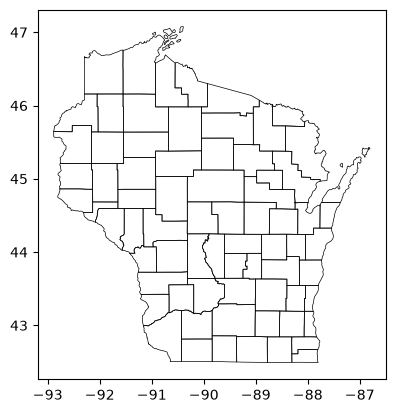

In [146]:
wis_gdf = gdf.loc[gdf['STATEFP']==wi_fp]
wis_gdf.plot(ec='k', lw=0.5, fc='None')

In [150]:
bus_meta = pd.read_csv(data_path/'Wisconsin_1664_BusMetaData.csv', skiprows=1)
bus_gdf = gpd.GeoDataFrame(bus_meta, geometry=gpd.points_from_xy(bus_meta.Longitude,bus_meta.Latitude), crs='EPSG:4269')

In [151]:
wis_gdf

,STATEFP,COUNTYFP,COUNTYNS,AFFGEOID,GEOID,NAME,LSAD,ALAND,AWATER,geometry
19,55,061,01581090,0500000US55061,55061,Kewaunee,06,886951858,1921336271,"POLYGON ((-87.76532 44.4145, -87.76238 44.6445..."
91,55,073,01581096,0500000US55073,55073,Marathon,06,4002224342,80462463,"POLYGON ((-90.31657 44.95328, -90.31504 45.033..."
94,55,107,01581114,0500000US55107,55107,Rusk,06,2366092053,44813690,"POLYGON ((-91.54029 45.6376, -90.67875 45.6382..."
101,55,119,01581119,0500000US55119,55119,Taylor,06,2525318793,24686414,"POLYGON ((-90.92522 45.29206, -90.92534 45.379..."
193,55,078,01581099,0500000US55078,55078,Menominee,06,926217568,19022479,"POLYGON ((-88.98218 45.11773, -88.93055 45.117..."
...,...,...,...,...,...,...,...,...,...,...
2965,55,091,01581106,0500000US55091,55091,Pepin,06,600894481,43241491,"POLYGON ((-92.31623 44.54097, -92.1353 44.5395..."
3053,55,069,01581094,0500000US55069,55069,Lincoln,06,2275833631,72744021,"POLYGON ((-90.04614 45.34031, -90.04227 45.381..."
3125,55,057,01581088,0500000US55057,55057,Juneau,06,1986622493,98737542,"POLYGON ((-90.31269 43.98138, -90.31252 44.155..."
3158,55,009,01581064,0500000US55009,55009,Brown,06,1372933176,221808928,"POLYGON ((-88.25256 44.67981, -88.24269 44.679..."


In [152]:
bus_gdf

,Number,Name,Labels All,Area Name,Zone Name,Nom kV,Latitude,Longitude,geometry
0,1,55071010100,NaN,1,1,69.0,44.242288,-87.593243,POINT (-87.59324 44.24229)
1,2,55101001501,NaN,1,1,69.0,42.822490,-87.824224,POINT (-87.82422 42.82249)
2,3,55059002602,NaN,1,1,69.0,42.526679,-87.908276,POINT (-87.90828 42.52668)
3,4,55089630100,NaN,1,1,69.0,43.388634,-87.875316,POINT (-87.87532 43.38863)
4,5,55021970600,NaN,1,1,69.0,43.516232,-89.477290,POINT (-89.47729 43.51623)
...,...,...,...,...,...,...,...,...,...
1659,1660,55139003000,NaN,1,1,230.0,44.199044,-88.467156,POINT (-88.46716 44.19904)
1660,1661,55139003702,NaN,1,1,230.0,44.149311,-88.496064,POINT (-88.49606 44.14931)
1661,1662,55141010400,NaN,1,1,138.0,44.642993,-90.160905,POINT (-90.1609 44.64299)
1662,1663,55141010500,NaN,1,1,138.0,44.647960,-90.190691,POINT (-90.19069 44.64796)


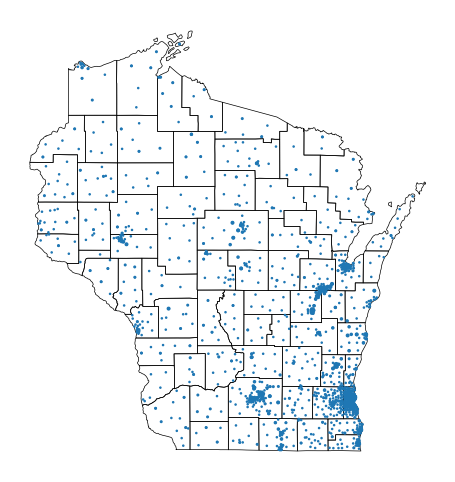

In [159]:
fig, ax = plt.subplots(figsize=(8,6))
wis_gdf.plot(ax=ax, ec='k', lw=0.5, fc='None')
bus_gdf.plot(ax=ax, markersize=bus_gdf['Nom kV']/1e2)
ax.set_axis_off()